### Content
- Plotting points with different colors intensity based on the frequency with which they have been recorded (both as starting/ending points of an e-scooters trip or in the middle of it) 
- Plotting trajectories of a random day with layer control to select trips
- Check most common stops of e-scooters trips (the most frequent considering all data for all days); barchart of frequency of all stops that appeared more than 50 times; map with stops that appeared more than 50 times, with markers of different colors based on their frequency
- use pyrosm to get data of location of public transport stops. Plot public transport stops and most frequent e-scooters trips stops, to check whether e-scooters concluded their ride near public transport stops, which means they may be used to commute to another form of transport (and not used just for fun – the use of e-scooters for very short paths suggest they may be used just for the fun of riding them, in which case they cannot be considered a real resource for sustainable mobility)

In [ ]:
try:
  import geopandas as gpd
except ModuleNotFoundError as e:
  !pip install geopandas==0.10.1
  import geopandas as gpd

if gpd.__version__ != "0.10.1":
  !pip install -U geopandas==0.10.1
  import geopandas as gpd

In [ ]:
try:
  import mapclassify
except ModuleNotFoundError as e:
  !pip install mapclassify
  import mapclassify

if mapclassify.__version__ != "2.4.3":
  !pip install -U mapclassify==2.4.3

In [ ]:
try:
  import contextily 
except ModuleNotFoundError as e:
  !pip install contextily==1.1.0
  import contextily

if contextily.__version__ != "1.1.0":
  !pip install -U contextily==1.1.0
  import contextily

In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np
import contextily as ctx
import matplotlib.pyplot as plt 

In [8]:
data = pd.read_parquet('trips_pointv3_cleaned.parquet')

In [9]:
data = gpd.GeoDataFrame(data, crs='EPSG:4326', geometry=gpd.points_from_xy(data.point_longitude, data.point_latitude))
data

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,date,unique_id,geometry
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12041 46.05297)
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12047 46.05295)
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12081 46.05291)
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12112 46.05287)
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12153 46.05273)
...,...,...,...,...,...,...,...,...,...,...
998804,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:41+00:00,46.079951,11.117475,3,2022-03-04,66cff91f-babc-4560-b5c3-a6cc53c6d371_2022-03-04,POINT (11.11748 46.07995)
998805,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:51+00:00,46.079677,11.117734,4,2022-03-04,66cff91f-babc-4560-b5c3-a6cc53c6d371_2022-03-04,POINT (11.11773 46.07968)
998806,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:01+00:00,46.079403,11.117844,5,2022-03-04,66cff91f-babc-4560-b5c3-a6cc53c6d371_2022-03-04,POINT (11.11784 46.07940)
998807,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:11+00:00,46.079176,11.117913,6,2022-03-04,66cff91f-babc-4560-b5c3-a6cc53c6d371_2022-03-04,POINT (11.11791 46.07918)


In [13]:
len(pd.unique(data.unique_id))

88059

In [14]:
data = data.astype({"point_latitude": float, "point_longitude": float}, errors='raise') 
type(data.point_latitude[0])

numpy.float64

In [15]:
data.groupby(['point_latitude','point_longitude']).size()

point_latitude  point_longitude
46.032254       11.132694          1
46.032287       11.132544          1
46.032296       11.132574          1
46.032297       11.132577          1
46.032302       11.132592          1
                                  ..
46.129533       11.115911          1
46.129564       11.116256          1
46.129699       11.116352          1
46.129783       11.116091          1
46.129791       11.116353          1
Length: 712398, dtype: int64

In [16]:
df = pd.DataFrame(data.groupby(['point_latitude','point_longitude']).size()).reset_index()
df = df.rename(columns={0:'freq'})
df

,point_latitude,point_longitude,freq
0,46.032254,11.132694,1
1,46.032287,11.132544,1
2,46.032296,11.132574,1
3,46.032297,11.132577,1
4,46.032302,11.132592,1
...,...,...,...
712393,46.129533,11.115911,1
712394,46.129564,11.116256,1
712395,46.129699,11.116352,1
712396,46.129783,11.116091,1


In [17]:
df = gpd.GeoDataFrame(df, crs='EPSG:4326', geometry=gpd.points_from_xy(df.point_longitude, df.point_latitude))

In [18]:
!pip install xyzservices 
import xyzservices.providers as xyz

Plotting points by frequency (not so significant after adding the new data)

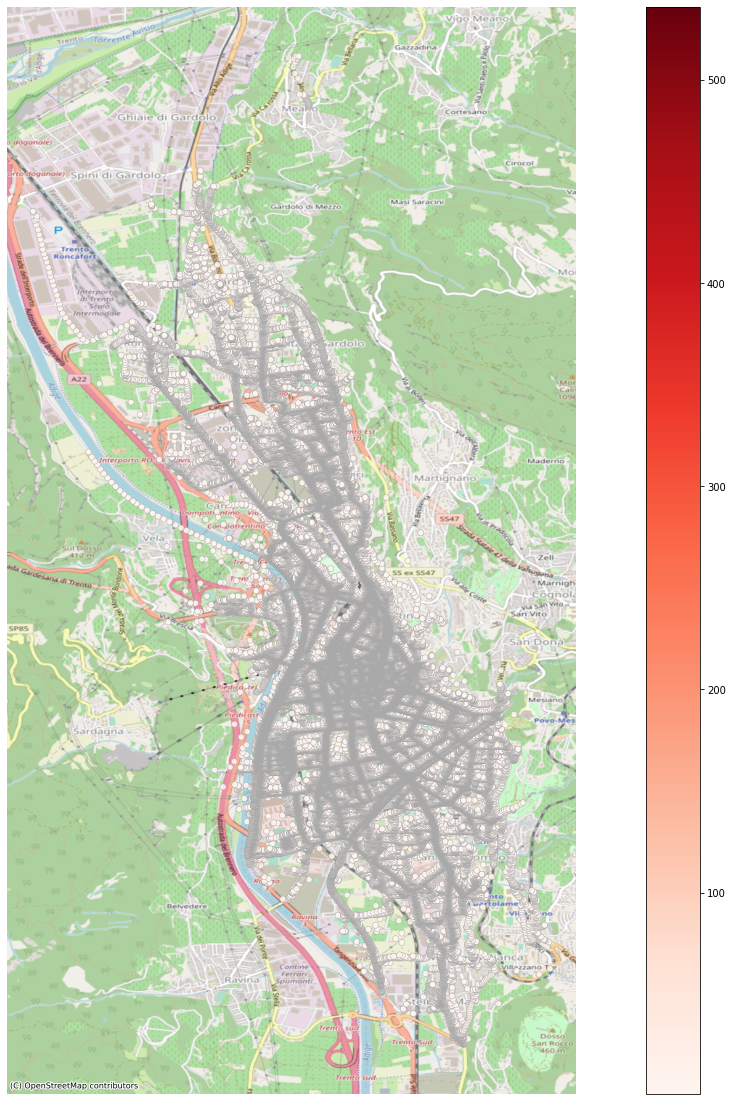

In [19]:
fig, ax = plt.subplots(1, figsize=(25,20)) 

df.to_crs(epsg=4326).plot(column="freq",
                    alpha=.9, cmap="Reds", edgecolor = "darkgrey", 
                    legend=True, linewidth = 0.5,     
                    ax=ax)

ctx.add_basemap(ax, crs=df.to_crs(epsg=4326).crs.to_string(),  
               source=xyz.OpenStreetMap.Mapnik)

ax.set_axis_off()

### Plotting trajectories of a random day

In [20]:
type(data.point_timestamp[0])
data_one_day = data[(data['point_timestamp'] >= '2022-02-20 00:00:00+00:00') & (data['point_timestamp'] < '2022-02-21 00:00:00+00:00')]
data_one_day = data_one_day.reset_index()
data_one_day


,index,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,date,unique_id,geometry
0,70059,VENTO,Tier,f836e2a5-7155-4979-914e-7c4a42533801,2022-02-20 00:00:03+00:00,46.071324,11.123489,105,2022-02-20,f836e2a5-7155-4979-914e-7c4a42533801_2022-02-20,POINT (11.12349 46.07132)
1,70060,VENTO,Tier,f836e2a5-7155-4979-914e-7c4a42533801,2022-02-20 00:00:13+00:00,46.071307,11.123580,106,2022-02-20,f836e2a5-7155-4979-914e-7c4a42533801_2022-02-20,POINT (11.12358 46.07131)
2,70061,VENTO,Tier,f836e2a5-7155-4979-914e-7c4a42533801,2022-02-20 00:00:23+00:00,46.071097,11.123536,107,2022-02-20,f836e2a5-7155-4979-914e-7c4a42533801_2022-02-20,POINT (11.12354 46.07110)
3,70062,VENTO,Tier,f836e2a5-7155-4979-914e-7c4a42533801,2022-02-20 00:00:33+00:00,46.070863,11.123080,108,2022-02-20,f836e2a5-7155-4979-914e-7c4a42533801_2022-02-20,POINT (11.12308 46.07086)
4,70063,VENTO,Tier,f836e2a5-7155-4979-914e-7c4a42533801,2022-02-20 00:00:44+00:00,46.070703,11.122555,109,2022-02-20,f836e2a5-7155-4979-914e-7c4a42533801_2022-02-20,POINT (11.12256 46.07070)
...,...,...,...,...,...,...,...,...,...,...,...
2470,72658,VENTO,Tier,91e6756d-5fb6-4280-9270-19280cb614b1,2022-02-20 17:31:11+00:00,46.079813,11.117463,38,2022-02-20,91e6756d-5fb6-4280-9270-19280cb614b1_2022-02-20,POINT (11.11746 46.07981)
2471,72659,VENTO,Tier,91e6756d-5fb6-4280-9270-19280cb614b1,2022-02-20 17:31:20+00:00,46.079771,11.117155,39,2022-02-20,91e6756d-5fb6-4280-9270-19280cb614b1_2022-02-20,POINT (11.11716 46.07977)
2472,72660,VENTO,Tier,91e6756d-5fb6-4280-9270-19280cb614b1,2022-02-20 17:31:37+00:00,46.079771,11.117155,40,2022-02-20,91e6756d-5fb6-4280-9270-19280cb614b1_2022-02-20,POINT (11.11716 46.07977)
2473,73179,BIT,Bit Mobility,000026ce-0000-1000-817e-5b7d6a617b60,2022-02-20 23:17:15+00:00,46.062135,11.113972,0,2022-02-20,000026ce-0000-1000-817e-5b7d6a617b60_2022-02-20,POINT (11.11397 46.06213)


In [21]:
new_df = data_one_day.groupby('point_trip_id', as_index=False).aggregate({"point_latitude": lambda x: x.to_list(),
                                                                          "point_longitude": lambda x: x.to_list()})
new_df

,point_trip_id,point_latitude,point_longitude
0,00000078-0000-1000-9298-5b7d6a617b60,"[46.0662, 46.060764]","[11.120246, 11.115386]"
1,00000087-0000-1000-8b27-5b7d6a617b60,"[46.0544, 46.074051]","[11.135522, 11.114924]"
2,000000d6-0000-1000-92d6-5b7d6a617b60,"[46.060513, 46.06185]","[11.125489, 11.129496]"
3,00000178-0000-1000-80f8-5b7d6a617b60,"[46.070167, 46.082212]","[11.119927, 11.122503]"
4,000001d6-0000-1000-8136-5b7d6a617b60,"[46.069272, 46.069272]","[11.113805, 11.113805]"
...,...,...,...
182,ecc9991f-cbdf-44d1-9b8d-fd792de18eef,"[46.057862, 46.057805, 46.057616, 46.057535, 4...","[11.118318, 11.118452, 11.118113, 11.117333, 1..."
183,edf32e17-1415-40c5-8683-71b47b90acc7,"[46.081897, 46.081834, 46.081886, 46.081759, 4...","[11.122242, 11.122198, 11.122175, 11.121713, 1..."
184,f836e2a5-7155-4979-914e-7c4a42533801,"[46.071324, 46.071307, 46.071097, 46.070863, 4...","[11.123489, 11.12358, 11.123536, 11.12308, 11...."
185,fd2a0aa0-2899-460a-ad17-2d6d969eeb5a,"[46.049404, 46.049404, 46.049369, 46.049429, 4...","[11.131429, 11.131429, 11.131348, 11.131339, 1..."


In [22]:
new_df["coords"] = [ [[k,v] for k,v in zip(i,j)] for i,j in zip(new_df["point_latitude"], new_df["point_longitude"])]
new_df

,point_trip_id,point_latitude,point_longitude,coords
0,00000078-0000-1000-9298-5b7d6a617b60,"[46.0662, 46.060764]","[11.120246, 11.115386]","[[46.0662, 11.120246], [46.060764, 11.115386]]"
1,00000087-0000-1000-8b27-5b7d6a617b60,"[46.0544, 46.074051]","[11.135522, 11.114924]","[[46.0544, 11.135522], [46.074051, 11.114924]]"
2,000000d6-0000-1000-92d6-5b7d6a617b60,"[46.060513, 46.06185]","[11.125489, 11.129496]","[[46.060513, 11.125489], [46.06185, 11.129496]]"
3,00000178-0000-1000-80f8-5b7d6a617b60,"[46.070167, 46.082212]","[11.119927, 11.122503]","[[46.070167, 11.119927], [46.082212, 11.122503]]"
4,000001d6-0000-1000-8136-5b7d6a617b60,"[46.069272, 46.069272]","[11.113805, 11.113805]","[[46.069272, 11.113805], [46.069272, 11.113805]]"
...,...,...,...,...
182,ecc9991f-cbdf-44d1-9b8d-fd792de18eef,"[46.057862, 46.057805, 46.057616, 46.057535, 4...","[11.118318, 11.118452, 11.118113, 11.117333, 1...","[[46.057862, 11.118318], [46.057805, 11.118452..."
183,edf32e17-1415-40c5-8683-71b47b90acc7,"[46.081897, 46.081834, 46.081886, 46.081759, 4...","[11.122242, 11.122198, 11.122175, 11.121713, 1...","[[46.081897, 11.122242], [46.081834, 11.122198..."
184,f836e2a5-7155-4979-914e-7c4a42533801,"[46.071324, 46.071307, 46.071097, 46.070863, 4...","[11.123489, 11.12358, 11.123536, 11.12308, 11....","[[46.071324, 11.123489], [46.071307, 11.12358]..."
185,fd2a0aa0-2899-460a-ad17-2d6d969eeb5a,"[46.049404, 46.049404, 46.049369, 46.049429, 4...","[11.131429, 11.131429, 11.131348, 11.131339, 1...","[[46.049404, 11.131429], [46.049404, 11.131429..."


In [23]:
new_df.sort_values(by="coords", key=lambda x: x.str.len())

,point_trip_id,point_latitude,point_longitude,coords
86,00001909-0000-1000-9f79-5b7d6a617b60,[46.066793],[11.120446],"[[46.066793, 11.120446]]"
0,00000078-0000-1000-9298-5b7d6a617b60,"[46.0662, 46.060764]","[11.120246, 11.115386]","[[46.0662, 11.120246], [46.060764, 11.115386]]"
95,00001a72-0000-1000-80d2-5b7d6a617b60,"[46.059568, 46.070731]","[11.115169, 11.1195]","[[46.059568, 11.115169], [46.070731, 11.1195]]"
96,00001a7e-0000-1000-924e-5b7d6a617b60,"[46.069287, 46.068998]","[11.113837, 11.125966]","[[46.069287, 11.113837], [46.068998, 11.125966]]"
97,00001a97-0000-1000-85e7-5b7d6a617b60,"[46.060558, 46.066846]","[11.115263, 11.120289]","[[46.060558, 11.115263], [46.066846, 11.120289]]"
...,...,...,...,...
172,b7b708a8-7440-4a66-9128-a12bec7cad34,"[46.069538, 46.069066, 46.068711, 46.068289, 4...","[11.127196, 11.127227, 11.126962, 11.126631, 1...","[[46.069538, 11.127196], [46.069066, 11.127227..."
167,a8f5ac67-bdec-4064-ae40-aba9ef5e32c8,"[46.065694, 46.065672, 46.065757, 46.065867, 4...","[11.125197, 11.125208, 11.125221, 11.12541, 11...","[[46.065694, 11.125197], [46.065672, 11.125208..."
176,c0907311-7b6f-4ee7-af24-2ecb1183145e,"[46.076845, 46.07684, 46.076839, 46.076985, 46...","[11.118946, 11.118931, 11.118771, 11.118336, 1...","[[46.076845, 11.118946], [46.07684, 11.118931]..."
179,dd9f435b-7d2e-4006-a41d-c7b20a46df41,"[46.057799, 46.057799, 46.057705, 46.057541, 4...","[11.11829, 11.11829, 11.118366, 11.117953, 11....","[[46.057799, 11.11829], [46.057799, 11.11829],..."


In [24]:
# extract ID of trip n. 173 (numerata partendo da 1) as an example of a trip that seem to contain error in the trajectory (fix with MovingPandas in another notebook)
print(new_df.at[172, 'point_trip_id'])
new_df.loc[(new_df.point_trip_id=='b7b708a8-7440-4a66-9128-a12bec7cad34')]

b7b708a8-7440-4a66-9128-a12bec7cad34


,point_trip_id,point_latitude,point_longitude,coords
172,b7b708a8-7440-4a66-9128-a12bec7cad34,"[46.069538, 46.069066, 46.068711, 46.068289, 4...","[11.127196, 11.127227, 11.126962, 11.126631, 1...","[[46.069538, 11.127196], [46.069066, 11.127227..."


In [26]:
import folium
from branca.element import Figure
import random

fig = Figure(height=550,width=750)
m = folium.Map(location=[46.066, 11.133], tiles='cartodbpositron', zoom_start=14)
fig.add_child(m)

n=1
  
for i in range(len(new_df)):
  points = []
  points.append(new_df.coords[i])
  feat = folium.FeatureGroup("Vehicle"+ str(n), show=False)
  
  popup = 'trip n. '+str(n)
  color = ["#"+''.join([random.choice('ABCDEF0123456789') for i in range(6)])]
  n+=1

  folium.vector_layers.PolyLine(points, popup=popup, tooltip=popup, color=color).add_to(feat)
  feat.add_to(m)


m.add_child(folium.LayerControl())

m



In [27]:
import folium
from  folium import plugins
m=folium.Map(width=750, height=550, location=[46.066, 11.133], zoom_start=14, min_zoom=8, max_zoom = 20)


n=1
  
for i in range(len(new_df)):
  points = []
  points.append(new_df.coords[i])
  popup = 'trip n. '+str(n)
  color = ["#"+''.join([random.choice('ABCDEF0123456789') for i in range(6)])]

  feat = folium.FeatureGroup("Vehicle"+ str(n), show=False)
  plugins.AntPath(points, popup=popup, tooltip=popup, **{'color':color}).add_to(feat)
  
  n+=1

  feat.add_to(m)


m.add_child(folium.LayerControl())




m

### Checking most common stops of e-scooters rides (end of trajectories)

In [28]:
# ending pt of trajectories
data
data["coords"] = [ (i,j) for i,j in zip(data["point_latitude"], data["point_longitude"])]
data

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,date,unique_id,geometry,coords
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12041 46.05297),"(46.052974, 11.120415)"
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12047 46.05295),"(46.052951, 11.120469)"
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12081 46.05291),"(46.052905, 11.120811)"
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12112 46.05287),"(46.052874, 11.121122)"
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.12153 46.05273),"(46.052732, 11.121525)"
...,...,...,...,...,...,...,...,...,...,...,...
998804,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:41+00:00,46.079951,11.117475,3,2022-03-04,66cff91f-babc-4560-b5c3-a6cc53c6d371_2022-03-04,POINT (11.11748 46.07995),"(46.079951, 11.117475)"
998805,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:06:51+00:00,46.079677,11.117734,4,2022-03-04,66cff91f-babc-4560-b5c3-a6cc53c6d371_2022-03-04,POINT (11.11773 46.07968),"(46.079677, 11.117734)"
998806,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:01+00:00,46.079403,11.117844,5,2022-03-04,66cff91f-babc-4560-b5c3-a6cc53c6d371_2022-03-04,POINT (11.11784 46.07940),"(46.079403, 11.117844)"
998807,VENTO,Tier,66cff91f-babc-4560-b5c3-a6cc53c6d371,2022-03-04 13:07:11+00:00,46.079176,11.117913,6,2022-03-04,66cff91f-babc-4560-b5c3-a6cc53c6d371_2022-03-04,POINT (11.11791 46.07918),"(46.079176, 11.117913)"


In [29]:
ending=[]

for id in range(len(data.point_trip_id)):
  if id==0:
    continue
  elif id==len(data.point_trip_id)-1:
    ending.append(data.coords[id])
  else:
    if data.point_trip_id[id] != data.point_trip_id[id+1]:
      ending.append(data.coords[id])
    else:
      continue

In [30]:
len(ending)

210424

In [31]:
from collections import Counter

print(Counter(ending))

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [32]:
d=Counter(ending)
coord=d.keys()
freq=d.values()


df = pd.DataFrame.from_dict({'coord':coord, 'freq':freq})

df.drop(df[df.freq < 50].index, inplace=True)

df = df.reset_index()
df = df.drop(columns=['index'])
df = df.sort_values(by=['freq'], ascending=False)
df.head()

,coord,freq
12,"(46.072396, 11.119825)",118
16,"(46.070462, 11.115893)",109
3,"(46.067035, 11.119006)",102
24,"(46.067022, 11.121241)",100
31,"(46.068661, 11.118867)",97


In [34]:
len(df)

43

In [35]:
from geopy.geocoders import Nominatim

# initialize Nominatim API 
geolocator = Nominatim(user_agent="geoapi")

place = {}
for row in range(len(df)):
  place[row] = geolocator.reverse(str(df.coord[row]))

In [36]:
df['location']=''
for row in range(len(df)):
  p = str(place[row]).split('(')
  p = p[0].split(',')
  df.at[row,'location']=p[0]+p[1]+p[2]+p[4]

df

,coord,freq,location
12,"(46.072396, 11.119825)",118,10 Piazza Dante Centro storico Trento Territor...
16,"(46.070462, 11.115893)",109,Pista Ciclabile Valle dell'Adige Laboratorio S...
3,"(46.067035, 11.119006)",102,29 Via Antonio Rosmini Bolghera Trento
24,"(46.067022, 11.121241)",100,Cattedrale di San Vigilio Piazza del Duomo Bol...
31,"(46.068661, 11.118867)",97,1 Piazza Santa Maria Maggiore Bolghera Trento
1,"(46.071117, 11.119426)",91,6/A Piazza Dante Bolghera Vela
19,"(46.083823, 11.114655)",89,Via Ezio Maccani Campotrentino Centochiavi Ter...
15,"(46.087407, 11.121387)",89,"Solteri / ""Nido La Trottola"" Via dei Solteri P..."
5,"(46.068614, 11.118748)",85,1 Piazza Santa Maria Maggiore Bolghera Trento
18,"(46.093196, 11.118366)",83,Tecnodata Trentina 24 Via Romano Guardini zona...


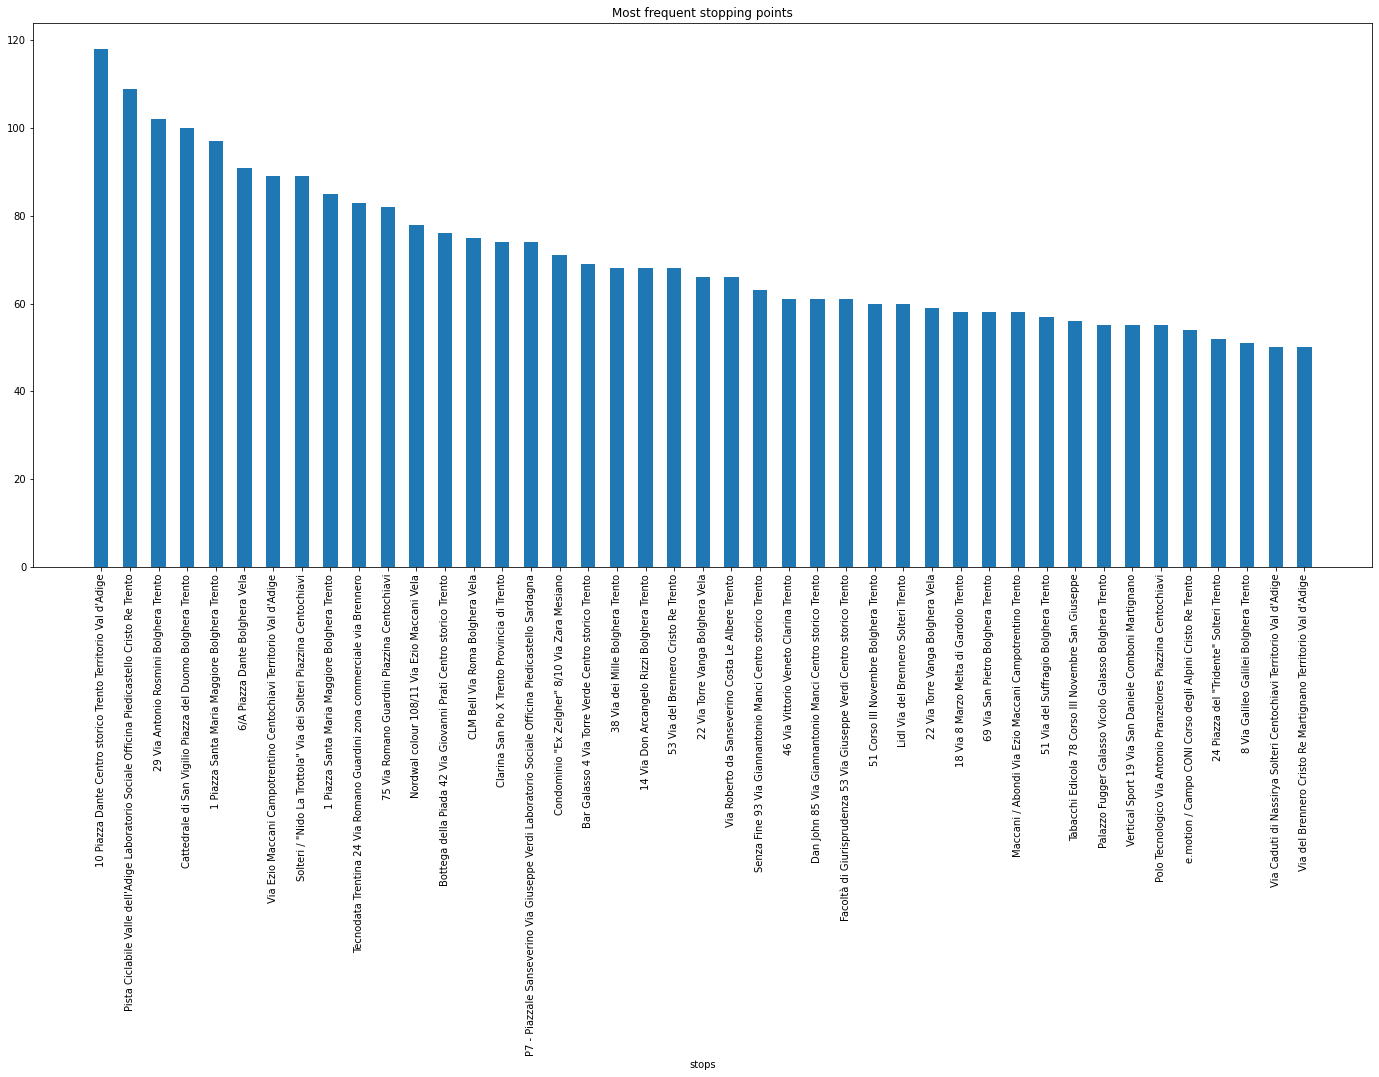

In [37]:
# plt.bar(np.arange(len(df.freq)), df.freq)
# plt.show()

fig = plt.figure(figsize=(24,10))

xs = np.arange(len(df.coord))

xs_labels = df.location.to_list()

ys = df.freq.to_list()

plt.bar(xs, ys, 0.5, align='center')

plt.title("Most frequent stopping points")
plt.xticks(xs, xs_labels, rotation=90)

plt.xlabel('stops')


plt.show()

In [46]:
def color_func(freq):
  if freq >= df.freq.mean(): # 70.5
    return 'green'
  elif freq<df.freq.mean() and freq>=df.freq.median(): # 66.0
    return 'orange'
  elif freq<df.freq.median():
    return 'red'


map = folium.Map(width=750, height=550, location=[46.066, 11.133], zoom_start=14, max_zoom=20)
for point in range(0, len(df.coord)):
  iframe = folium.IFrame(df['location'][point], width=500, height=50) 
  popup = folium.Popup(iframe)
  folium.Marker(df.coord[point], popup=popup, icon=folium.Icon(color=color_func(df.freq[point]), icon_color='white')).add_to(map)
map

### Try to understand if the e-scooters are used to commute to another means of transport by checking if the ending points of the trip are close to public transport stops

In [ ]:
try:
  import pyrosm
except ModuleNotFoundError as e:
  !pip install pyrosm==0.6.1
  import pyrosm

In [49]:
import os
import sys 
from google.colab import drive 
import glob

path = "/content/drive" 
drive.mount(path, force_remount=True)  
data_path = "drive/MyDrive/Colab Notebooks/escooter_TN" 

myfiles = glob.glob(os.path.join(data_path, '*')) 
print(myfiles)

Mounted at /content/drive
['drive/MyDrive/Colab Notebooks/escooter_TN/trento.pbf', 'drive/MyDrive/Colab Notebooks/escooter_TN/dataviz_spostamenti.html', 'drive/MyDrive/Colab Notebooks/escooter_TN/dataviz_spostamenti_monopattini.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/traiettorie_con_MovingPandas.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/check_datasets-delete.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/0_clean_data.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/trips_pointv3_cleaned.parquet', 'drive/MyDrive/Colab Notebooks/escooter_TN/ExploreTrips.ipynb', 'drive/MyDrive/Colab Notebooks/escooter_TN/traiettorie.ipynb']


In [58]:
import os
trento_download_pbf_url = "https://osmit-estratti.wmcloud.org/dati/poly/comuni/pbf/022205_Trento_poly.osm.pbf"
# download the data
import requests
#request the file
r = requests.get(trento_download_pbf_url, allow_redirects=True)
#save the file
open(data_path+'/trento.pbf', 'wb').write(r.content)

3799841

In [69]:
osm = pyrosm.OSM(data_path+"/trento.pbf")
osm.conf.tags.available

['aerialway',
 'aeroway',
 'amenity',
 'boundary',
 'building',
 'craft',
 'emergency',
 'geological',
 'highway',
 'historic',
 'landuse',
 'leisure',
 'natural',
 'office',
 'power',
 'public_transport',
 'railway',
 'route',
 'place',
 'shop',
 'tourism',
 'waterway']

In [ ]:
custom_filter = {'public_transport': True}
pois = osm.get_pois(custom_filter=custom_filter)
pois

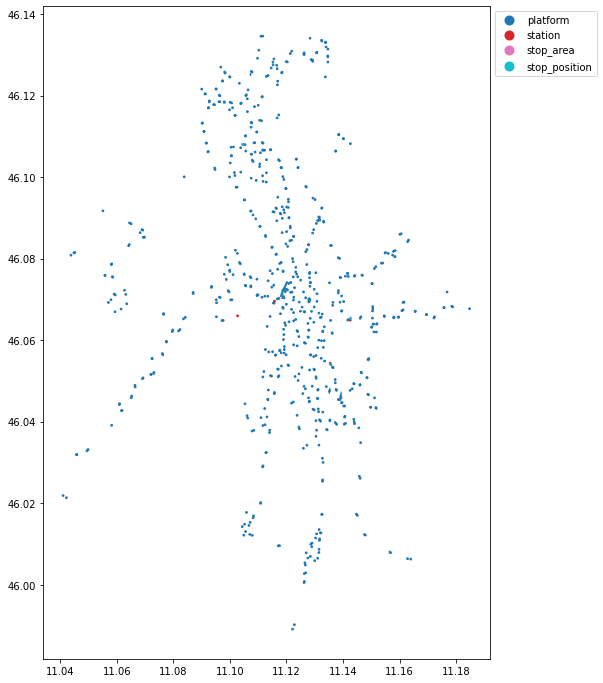

In [ ]:
pois["poi_type"] = pois["public_transport"]
pois["poi_type"] = pois["poi_type"].fillna(pois["public_transport"])

# Plot
ax = pois.plot(column='poi_type', markersize=3, figsize=(12,12), legend=True, legend_kwds=dict(loc='upper left', ncol=1, bbox_to_anchor=(1, 1)))

In [ ]:
pois = pois.dropna(subset=['lon','lat'])
pois.head()

,id,lon,version,timestamp,tags,lat,changeset,addr:housenumber,addr:street,name,operator,ref,public_transport,geometry,osm_type,poi_type
0,248009842,11.139458,9,1645443129,"{""highway"":""bus_stop"",""shelter"":""no""}",46.067120,0.0,None,None,"Mesiano / ""Fac. Ingegneria""",None,None,platform,POINT (11.13946 46.06712),node,platform
1,248049459,11.136446,22,1645443129,"{""bench"":""no"",""bin"":""yes"",""highway"":""bus_stop""...",46.069290,0.0,None,None,"Valsugana / ""Corallo""",None,None,platform,POINT (11.13645 46.06929),node,platform
2,248049727,11.139605,9,1645443129,"{""highway"":""bus_stop"",""shelter"":""yes"",""tactile...",46.067230,0.0,None,None,"Mesiano / ""Fac. Ingegneria""",None,None,platform,POINT (11.13960 46.06723),node,platform
3,248050135,11.138317,10,1573574250,"{""bus"":""yes"",""highway"":""bus_stop""}",46.071602,0.0,None,None,San Donà,None,None,platform,POINT (11.13832 46.07160),node,platform
4,248050308,11.140239,10,1631289227,"{""bench"":""no"",""bin"":""yes"",""bus"":""yes"",""highway...",46.069496,0.0,None,None,"""Ponte Lodovico""",None,None,platform,POINT (11.14024 46.06950),node,platform


In [ ]:
transport=[]
for row in range(len(pois)):
  transport.append((pois.lat[row], pois.lon[row]))

In [ ]:
import folium
from folium.plugins import BeautifyIcon

map = folium.Map(width=750, height=550, location=[46.066, 11.133], zoom_start=14)

# public transports
for pt in transport:
  icon_circle = BeautifyIcon(icon_shape='circle-dot', border_color='green', border_width=5)
  folium.Marker(pt, tooltip='public transport stop', icon=icon_circle).add_to(map)

# ending points trips
for point in range(0, len(df.coord)):
  iframe = folium.IFrame(df['location'][point] + '<br>Frequency: ' + str(df['freq'][point]), width=500, height=50) 
  popup = folium.Popup(iframe)
  folium.Marker(df.coord[point], popup=popup, icon=folium.Icon(color=color_func(df.freq[point]), icon_color='white')).add_to(map)

map
